In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

!pip install Sastrawi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import hstack

path = "/content/drive/MyDrive/SEMESTER 6/DATA/Twitter_Emotion_Dataset.csv"
df = pd.read_csv(path)

print(f"Dataset dimuat: {df.shape[0]} baris")
df.head()
print(df['label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset dimuat: 4401 baris
label
anger      1101
happy      1017
sadness     997
fear        649
love        637
Name: count, dtype: int64


In [ ]:
# Dictionary Slang
slang_dict = {
    " bgt ":" banget ", " gak ":" tidak ", " gak ":" tidak ", " yg ":" yang ",
    " dngn ":" dengan ", " sdh ":" sudah ", " tdk ":" tidak ", " jgn ":" jangan ",
    " km ":" kamu ", " sy ":" saya ", " gw ":" saya ", " lo ":" kamu ",
    " krn ":" karena ", " klo ":" kalau ", " tp ":" tapi ", " emang ":" memang "
}

def preprocess_academic(text):
    # 1. Case Folding
    text = text.lower()

    # 2. Hapus Tagging Dataset
    text = re.sub(r'\[username\]|\[url\]|\[sensitive-no\]', '', text)

    # 3. Hapus Karakter Spesial (Email, Mention diluar tag, dll)
    text = re.sub(r'@[^\s]+', '', text)

    # 4. Normalisasi Slang
    for slang, formal in slang_dict.items():
        text = text.replace(slang, formal)

    # 5. Hapus Angka dan Tanda Baca
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Hapus Spasi Berlebih
    text = ' '.join(text.split())

    return text

df['text_clean'] = df['tweet'].apply(preprocess_academic)

# Proses Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()
df['text_clean'] = df['text_clean'].apply(stemmer.stem)

print("Preprocessing & Stemming Selesai.")

Preprocessing & Stemming Selesai.


In [ ]:
# 1. Fitur Panjang Karakter & Kata
df['char_count'] = df['tweet'].apply(len)
df['word_count'] = df['tweet'].apply(lambda x: len(x.split()))

# 2. Fitur Tanda Baca (Sangat penting untuk emosi)
df['excl_count'] = df['tweet'].apply(lambda x: x.count('!'))
df['ques_count'] = df['tweet'].apply(lambda x: x.count('?'))

# 3. Fitur Uppercase (Marah biasanya pakai Caps Lock)
df['upper_ratio'] = df['tweet'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x)>0 else 0)

# Normalisasi Fitur Manual (0 sampai 1)
scaler = MinMaxScaler()
manual_features = scaler.fit_transform(df[['char_count', 'word_count', 'excl_count', 'ques_count', 'upper_ratio']])

print("Manual Feature Engineering Selesai.")

Manual Feature Engineering Selesai.


In [ ]:
# TF-IDF dengan N-Gram (1,3)
tfidf_vect = TfidfVectorizer(ngram_range=(1,3), max_features=5000)
X_tfidf = tfidf_vect.fit_transform(df['text_clean'])

# Gabungan TF-IDF dan Manual Features menggunakan hstack
X_combined = hstack([X_tfidf, manual_features])

# Label Encoding
le = LabelEncoder()
y = le.fit_transform(df['label'])

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total Fitur yang digunakan: {X_combined.shape[1]}")

Total Fitur yang digunakan: 5005


In [ ]:
# Tuning SVM agar akurasi maksimal
svm = SVC(probability=True)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print(f"Parameter Terbaik: {grid_search.best_params_}")
print("--- Laporan Klasifikasi SVM ---")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Parameter Terbaik: {'C': 10, 'kernel': 'rbf'}
--- Laporan Klasifikasi SVM ---
              precision    recall  f1-score   support

       anger       0.60      0.71      0.65       220
        fear       0.84      0.55      0.67       130
       happy       0.63      0.59      0.61       204
        love       0.91      0.67      0.77       127
     sadness       0.46      0.58      0.52       200

    accuracy                           0.63       881
   macro avg       0.69      0.62      0.64       881
weighted avg       0.66      0.63      0.63       881



In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# Tokenisasi untuk Deep Learning
max_words = 10000
max_len = 60
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text_clean'])

X_seq = pad_sequences(tokenizer.texts_to_sequences(df['text_clean']), maxlen=max_len)
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y, test_size=0.2, random_state=42)

# Arsitektur LSTM (Bidirectional)
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early Stopping untuk mencegah Overfitting
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32,
                    validation_data=(X_test_seq, y_test_seq), callbacks=[es])

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.2716 - loss: 1.5554 - val_accuracy: 0.4291 - val_loss: 1.3496
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.5622 - loss: 1.1167 - val_accuracy: 0.5743 - val_loss: 1.0600
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.7807 - loss: 0.6445 - val_accuracy: 0.6402 - val_loss: 0.9859
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8963 - loss: 0.3377 - val_accuracy: 0.6481 - val_loss: 1.2412
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.9543 - loss: 0.1697 - val_accuracy: 0.6107 - val_loss: 1.4818
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9756 - loss: 0.1013 - val_accuracy: 0.5993 - val_loss: 1.8244


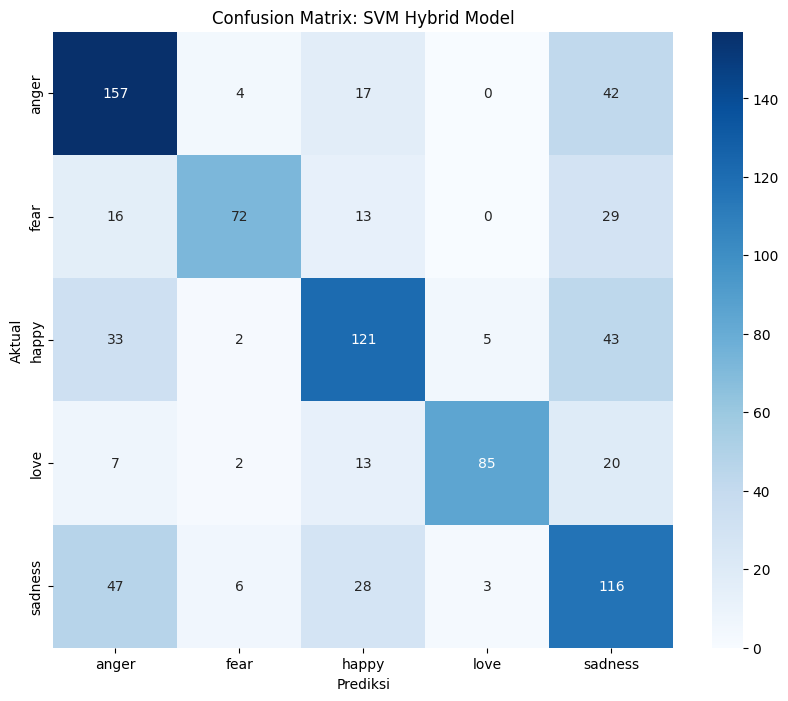

/tmp/ipykernel_4136/32082633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis')


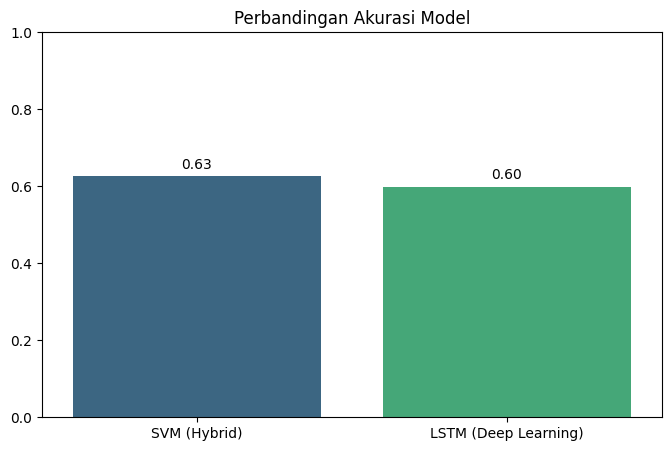

In [ ]:
# Confusion Matrix untuk melihat kesalahan prediksi
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: SVM Hybrid Model')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Visualisasi Perbandingan Model
models = ['SVM (Hybrid)', 'LSTM (Deep Learning)']
scores = [accuracy_score(y_test, y_pred_svm), history.history['val_accuracy'][-1]]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=scores, palette='viridis')
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi Model')
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()

In [ ]:
# Mengambil teks asli dari X_test
_, X_test_raw, _, _ = train_test_split(df['tweet'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

# Membuat DataFrame Hasil
df_hasil = pd.DataFrame({
    'Tweet Asli': X_test_raw.values,
    'Label Sebenarnya': le.inverse_transform(y_test),
    'Prediksi SVM': le.inverse_transform(y_pred_svm)
})

# Menambahkan kolom cek (Benar/Salah)
df_hasil['Status'] = np.where(df_hasil['Label Sebenarnya'] == df_hasil['Prediksi SVM'], '✅ BENAR', '❌ SALAH')

# Menampilkan 20 data pertama
print("--- Tabel Sampel Hasil Klasifikasi ---")
display(df_hasil.head(50))

--- Tabel Sampel Hasil Klasifikasi ---


,Tweet Asli,Label Sebenarnya,Prediksi SVM,Status
0,Untunge mereka tanggung jawab (kasih kaos gant...,happy,anger,❌ SALAH
1,"Di kasus Via Vallen ini gue kadang mikir, mrek...",anger,anger,✅ BENAR
2,Segala sesuatu yang kupelajari selalu saling j...,sadness,sadness,✅ BENAR
3,"Ceritanya semalam mau bubar, eh doi banyak tug...",happy,sadness,❌ SALAH
4,[USERNAME] [USERNAME] yg di bahas itu penting ...,anger,anger,✅ BENAR
5,Pulanglah... Pulang untuk mengisi peluk yang t...,sadness,sadness,✅ BENAR
6,"Semilir angin sore, tidak ada deru berisik kot...",happy,sadness,❌ SALAH
7,"Kalian semua boleh berasumsi, tapi tolong bija...",anger,anger,✅ BENAR
8,[USERNAME] [USERNAME] [USERNAME] [USERNAME] ne...,love,anger,❌ SALAH
9,Ada untungnya punya adik tuli. Bisa ngobrol ba...,happy,happy,✅ BENAR
